## Week 2 Day 3

Now we get to more detail:

1. Different models

2. Structured Outputs

3. Guardrails

In [4]:
from dotenv import load_dotenv
from openai import AsyncOpenAI
from agents import Agent, Runner, trace, function_tool, OpenAIChatCompletionsModel, output_guardrail, GuardrailFunctionOutput
import os
from pydantic import BaseModel, Field
import pprint

In [32]:
load_dotenv(override=True)

True

In [33]:
openai_api_key = os.getenv('OPENAI_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')
openrouter_api_key = os.getenv('OPENROUTER_API_KEY')
groq_api_key = os.getenv('GROQ_API_KEY')

if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")

if google_api_key:
    print(f"Google API Key exists and begins {google_api_key[:2]}")
else:
    print("Google API Key not set (and this is optional)")

if  openrouter_api_key:
    print(f"OpenRouter API Key exists and begins {openrouter_api_key[:6]}")
else:
    print("OpenRouter API Key not set (and this is optional)")

if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:4]}")
else:
    print("Groq API Key not set (and this is optional)")

OpenAI API Key exists and begins sk-proj-
Google API Key exists and begins AI
OpenRouter API Key exists and begins sk-or-
Groq API Key exists and begins gsk_


In [7]:
instructions = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write compelling sales emails that are likely to get a response.
"""

### It's easy to use any models with OpenAI compatible endpoints in 3 steps:

STEP 1: Find the OpenAI compatible base URL (see Guide 9 in the guides folder)

In [8]:
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
GROQ_BASE_URL = "https://api.groq.com/openai/v1"

STEP 2: Create a python client library instance (the async version)

In [34]:
# AsyncOpenAI() because we are using OpenAI framework which is async. If we were using a sync framework, we would use OpenAI() instead.
gemini_client = AsyncOpenAI(base_url=GEMINI_BASE_URL, api_key=google_api_key)
openrouter_client = AsyncOpenAI(base_url=OPENROUTER_BASE_URL, api_key=openrouter_api_key)
groq_client = AsyncOpenAI(base_url=GROQ_BASE_URL, api_key=groq_api_key)

STEP 3: Create a model object

In [35]:
gemini_model = OpenAIChatCompletionsModel(model="gemini-3.1-flash-lite", openai_client=gemini_client)
kimi_model = OpenAIChatCompletionsModel(model="moonshotai/kimi-k2.6", openai_client=openrouter_client)
oss_model = OpenAIChatCompletionsModel(model="openai/gpt-oss-120b", openai_client=groq_client)

In [36]:
# if we have model="gpt-5-mini" (provided model as string), then it uses OpenAI models by default. 
# But in the case of Gemini, Kimi, and GPT-OSS, we need to provide the model as an OpenAIChatCompletionsModel object 
# with the appropriate client. 

sales_agent1 = Agent(name="Gemini Sales Agent", instructions=instructions, model=gemini_model)
sales_agent2 = Agent(name="Kimi Sales Agent", instructions=instructions, model=kimi_model)
sales_agent3 = Agent(name="GPT-OSS Sales Agent",instructions=instructions, model=oss_model)

In [12]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."

tool1 = sales_agent1.as_tool(tool_name="sales_agent1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_agent2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_agent3", tool_description=description)

In [13]:
from messenger import send_email, push

USE_EMAIL = False

def send_message(subject, text_body, html_body):
    if USE_EMAIL:
        send_email(subject, text_body, html_body)
    else:
        push(f"Subject: {subject}\n\n{text_body}")

In [14]:
send_message("Yet another test", "Hooray!", "<html><body><h1>Hooray!</h1></body></html>")

Push: Subject: Yet another test

Hooray!


In [15]:
@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Send out an email with the given subject and body to all sales prospects
    
    Args:
        subject: The subject of the email
        text_body: The body of the email as plain text
        html_body: The HTML body of the email
    """
    send_message(subject, text_body, html_body)
    return "Email sent successfully"

In [16]:
tools = [tool1, tool2, tool3, send_email_tool]

In [17]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_agent tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_agent tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model="gpt-5.4-mini")

In [18]:
with trace("Sales Manager across different models"):
    result = await Runner.run(sales_manager, task)
print(result.final_output)

Push: Subject: Cut Your SOC 2 Audit Time in Half with AI-Powered Automation

Hi [First Name],

I know how draining the SOC 2 journey can be—endless spreadsheets, scattered evidence, and last-minute scramble before the auditor walks in. That’s why we built ComplAI, the AI-driven platform that turns a months-long, manual grind into a smooth, continuous compliance workflow.

What you’ll get with ComplAI:
- Automated data pull from AWS, GCP, Azure, SaaS apps, and on-prem tools
- AI-powered gap analysis that maps your policies to the five SOC 2 Trust Service Criteria
- Pre-filled audit packages and real-time readiness scorecard
- Continuous monitoring and alerts for control drift

Our customers typically see a 50-70% reduction in audit preparation time and a measurable drop in audit findings after the first quarter.

I’d love to run a 15-minute discovery call to see how ComplAI can fit into your current workflow and show you a live demo of the evidence-collection bot.

Are you available Tue

## Check out the trace

https://platform.openai.com/traces

## Part 2: Structured Outputs

An LLM produces text in natural language. But we can have it instead produce a "python object".

This is accomplished using the usual trickery: clever prompts & json!

1. We specify a Python object  
2. In the System prompt, the LLM is instructed to respond in JSON and follow a Schema which represents the Python object  
3. The LLM outputs JSON, and the framework populates a Python object based on it

When we specify the Python object, we create a subclass of BaseModel, which is part of the Pydantic framework.

Pydantic is a framework that easily allows defining a JSON schema and mapping between Python and json.

NOTES:

1. There is something about the way this is done that IS really clever - if you're interested, look up "constrained decoding".
2. Not all providers support Structured Outputs.


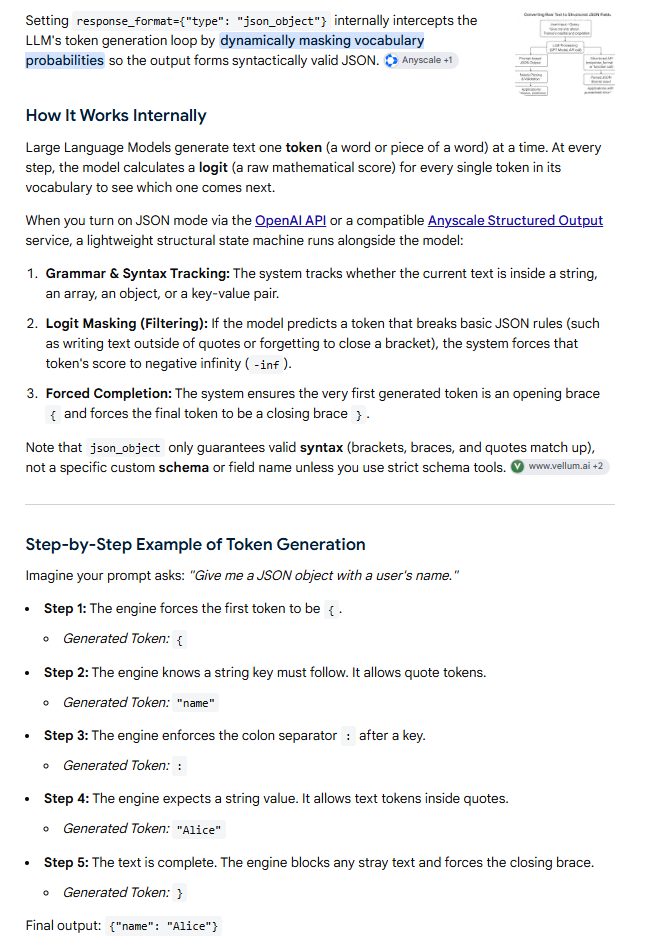

In [19]:
class EmailReview(BaseModel):
    is_professional: bool = Field(description="Whether the email is professional and appropriate")
    number_of_sentences: int = Field(description="The number of sentences in the body of the email, not including the greeting and signature")
    contains_placeholders: bool = Field(description="Whether the email contains placeholders for personalization")

In [21]:
EmailReview.model_json_schema()

{'properties': {'is_professional': {'description': 'Whether the email is professional and appropriate',
   'title': 'Is Professional',
   'type': 'boolean'},
  'number_of_sentences': {'description': 'The number of sentences in the body of the email, not including the greeting and signature',
   'title': 'Number Of Sentences',
   'type': 'integer'},
  'contains_placeholders': {'description': 'Whether the email contains placeholders for personalization',
   'title': 'Contains Placeholders',
   'type': 'boolean'}},
 'required': ['is_professional',
  'number_of_sentences',
  'contains_placeholders'],
 'title': 'EmailReview',
 'type': 'object'}

In [22]:
checker = Agent(name="Checker", instructions="You review potential sales emails", model="gpt-5.4-mini", output_type=EmailReview)

In [23]:
# user prompt
email = """
Hi [first_name],

I'm hitting you up to see if you'd like to buy our product. It's really great. You'll miss out if you don't buy it.

Laters.

Ed
"""

# run the checker agent to review the email
result = await Runner.run(checker, email)

In [24]:
review = result.final_output
review

EmailReview(is_professional=False, number_of_sentences=3, contains_placeholders=True)

In [25]:
review.is_professional

False

## Part 3: Guardrails

Guardrails are extremely important in AgenticAI. Put simply, they are controls that you code either in logic or with another LLM call, to prevent undesirable behavior.

For me, the Guardrails impementation in OpenAI Agents SDK feels a bit like "framework voodoo". I suspect their motivation was to show framework-level controls to address this important topic.

But it's simple and clean to implement guardrails explicitly, as separate Runner.run() calls, or checks in your tool implementations.

Regardless - let's take a look at the framework tooling.

https://openai.github.io/openai-agents-python/guardrails/


<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Watch out for a Gotcha</h2>
            <span style="color:#ff7800;">There are 3 types of Guardrails in OpenAI Agents SDK: input, output and tool. Input guardrails only run for the first input to the first Agent in Runner.run(). Output guardrails only run for the final output of the last agent. If you have guardrails on other agents, they will never be called.
            </span>
        </td>
    </tr>
</table>

In [28]:
@output_guardrail
async def email_guardrail(ctx, agent, message):
    print(f"Guardrail: Reviewing email with {agent.name}")
    print(f"Guardrail: Message to review:\n{message}")
    print(f"Guardrail: Context: {ctx.context}")
    
    result = await Runner.run(checker, message, context=ctx.context)
    review = result.final_output
    is_problem = review.contains_placeholders or not review.is_professional
    return GuardrailFunctionOutput(output_info={"review": review},tripwire_triggered=is_problem)

In [37]:
cowboy_instructions = instructions + "\nSpeak like a cowboy"

sales_agent_cowboy = Agent(name="Cowboy", instructions=cowboy_instructions, model=gemini_model, output_guardrails=[email_guardrail])

In [38]:
result = await Runner.run(sales_agent_cowboy, "Write a cold sales email")
result.final_output

Guardrail: Reviewing email with Cowboy
Guardrail: Message to review:
Howdy partner,

I reckon you’re tired of siftin’ through piles of compliance paperwork like a prospector lookin’ for a gold nugget in a mud puddle. Out here at ComplAI, we’ve got a system that’ll round up your regulatory headaches and brand ‘em done before the sun hits high noon.

We’re lookin’ to help folks like yourself stop chasin’ shadows and start spendin’ more time on the work that actually puts coin in your pocket. 

You got a minute this week to chat, or are you fixin’ to keep wranglin’ those reports the hard way?

Best trails,

[Your Name]
Sales Manager, ComplAI
Guardrail: Context: None


OutputGuardrailTripwireTriggered: Guardrail OutputGuardrail triggered tripwire

Check out the trace:

https://platform.openai.com/traces

## On the other hand..

To state the obvious, this is simpler and will work in any framework

In [39]:
simple_cowboy = Agent(name="Simple Cowboy", instructions=cowboy_instructions, model=gemini_model)
result = await Runner.run(simple_cowboy, "Write a cold sales email")
email = result.final_output
print(email)


Howdy partner. If you’re lookin’ to wrangle some results and stop leavin’ leads wanderin’ aimlessly out on the range, you’ve come to the right place. At ComplAI, we don't just graze; we hunt down the inefficiencies that are costin' your outfit money.

Here is the email that’ll get ’em corralled:

***

**Subject: A more efficient way to herd your leads, [Prospect Name]?**

Howdy [Prospect Name],

I’ve been keepin’ an eye on [Company Name] from the ridge, and I reckon you’re growin’ faster than a weed after a spring rain. But with that kind of speed, it’s easy for some of your best prospects to go stray.

At ComplAI, we’ve built a tool that helps teams like yours automate the grit work so you can spend your time closin’ deals instead of chasin’ shadows. We’ve helped folks in [Prospect's Industry] tighten up their sales process and rustle up a whole lot more revenue in the process.

I’d be obliged if you had ten minutes this week to chew the fat and see if we can help you round up some be

In [40]:
result = await Runner.run(checker, email)
review = result.final_output
if not review.is_professional or review.contains_placeholders:
    print("The email is not professional or has placeholders and will not be sent")
else:
    print("Email is good")

The email is not professional or has placeholders and will not be sent


## Check out the trace:

https://platform.openai.com/traces

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">• Try different models<br/>• Add more input and output guardrails<br/>• Use structured outputs for the email generation
            </span>
        </td>
    </tr>
</table>

## OPTIONAL EXTRA: Sandbox Agents

This example will only work on Windows + WSL2, or Mac, or Linux

https://openai.github.io/openai-agents-python/sandbox_agents/

This is an execution harness - a runtime - "a persistent workspace where it can search large document sets, edit files, run commands, generate artifacts, and pick work back up from saved sandbox state."

You have to set up:
1. Manifest: the workspace
2. Capabilities: what it can do
3. SandboxRunConfig: where it runs

In [41]:
from pathlib import Path
from agents.run import RunConfig
from agents.sandbox import Manifest, SandboxAgent, SandboxRunConfig, SandboxPathGrant
from agents.sandbox.capabilities import Capabilities
from agents.sandbox.entries import LocalDir
from agents.sandbox.sandboxes.unix_local import UnixLocalSandboxClient

ImportError: UnixLocalSandbox is not supported on Windows. Use DockerSandboxClient or another sandbox backend.

In [ ]:
CODE_DIR = Path("code").resolve()
OUTPUT_DIR = Path("output").resolve()
if not OUTPUT_DIR.exists():
    OUTPUT_DIR.mkdir()

In [ ]:
CODE_DIR

In [ ]:
instructions = f"""
You are a software engineer that fixes bugs.
Review files in the sandbox code directory.

Write the fixed version of the file to this host output directory:
{OUTPUT_DIR}

Use full file paths when writing output.
Respond with a summary of what you did.
"""

In [ ]:
manifest = Manifest(entries={"code": LocalDir(src=CODE_DIR)}, extra_path_grants=[SandboxPathGrant(path=str(OUTPUT_DIR))])
capabilities = Capabilities.default()
capabilities

In [ ]:
run_config = RunConfig(sandbox=SandboxRunConfig(client=UnixLocalSandboxClient()), workflow_name="Sandbox coding example")

In [ ]:
agent = SandboxAgent(name="Engineer", instructions=instructions, model="gpt-5.4-mini", default_manifest=manifest, capabilities=capabilities)

In [ ]:
result = await Runner.run(agent, "Fix the bug in the code", run_config=run_config)
print(result.final_output)

## OPTIONAL EXTRA: MCP Teaser!

In [42]:
from agents.mcp import MCPServerStreamableHttp

In [43]:
task = """
In the new SandboxAgents feature in the OpenAI Agents SDK as of May 2026, what is the role of the Manifest object?
Always be accurate. If you don't know the answer, say so.
"""

In [44]:
agent = Agent(name="Expert", instructions="Answer the question", model="gpt-4o-mini")
result = await Runner.run(agent, task)
print(result.final_output)

As of my last knowledge update in October 2021, I don't have specific details about features released after that date, including the SandboxAgents feature in the OpenAI Agents SDK as of May 2026. Therefore, I cannot provide accurate information about the role of the Manifest object in that context. For the most accurate and up-to-date information, please refer to the official OpenAI documentation or announcements.


In [45]:
params = {"url": "https://mcp.context7.com/mcp", "timeout": 60}


async with MCPServerStreamableHttp(name="Context7", params=params) as server:
    agent = Agent(name="Expert", instructions="Use Context7 to answer the question", mcp_servers=[server], model="gpt-4o-mini")
    result = await Runner.run(agent, task)

print(result.final_output)

In the OpenAI Agents SDK, the **Manifest object** plays a crucial role in configuring the execution environment for **Sandbox Agents**. Specifically, it allows you to define permissions, path grants, and user access for sandboxed operations.

### Key Functions of the Manifest

1. **Path Grants**:
   - You can specify specific absolute paths that the sandbox is allowed to access. This includes assigning read-only access to certain directories.
   - Example:
     ```python
     manifest = Manifest(
         extra_path_grants=(
             SandboxPathGrant(path="/tmp"),
             SandboxPathGrant(path="/opt/toolchain", read_only=True),
         ),
     )
     ```

2. **User Permissions**:
   - The Manifest allows you to define users and their associated permissions regarding directory access within the sandbox, facilitating controlled execution environments. 
   - For instance, you can grant a user read access to a data directory while allowing write access to an output directory:
   

In [46]:
import json

data = {
    "type": "text",
    "text": """Available Libraries:

- Title: OpenAI Agents Python
- Context7-compatible library ID: /openai/openai-agents-python
- Description: The OpenAI Agents SDK is a framework for building multi-agent workflows, supporting various LLMs and featuring agents, handoffs, guardrails, sessions, and tracing.
- Code Snippets: 1873
- Source Reputation: High
- Benchmark Score: 90.1
- Versions: v0_2_9, v0.7.0
----------
- Title: OpenAI Agents Python
- Context7-compatible library ID: /websites/openai_github_io_openai-agents-python
- Description: The OpenAI Agents SDK enables building agentic AI apps with lightweight primitives like Agents, Handoffs, Guardrails, and Sessions, featuring built-in tracing for visualization and debugging.
- Code Snippets: 3695
- Source Reputation: High
- Benchmark Score: 86.33
----------
- Title: OpenAI Agents SDK
- Context7-compatible library ID: /websites/openai_github_io_openai-agents-python_zh
- Description: OpenAI Agents SDK is a production-ready Python package for building agent-based AI applications with lightweight, easy-to-use components like LLMs with tools, task delegation, and safety measures.
- Code Snippets: 778
- Source Reputation: High
- Benchmark Score: 49.5
----------
- Title: OpenAI Agents JS
- Context7-compatible library ID: /openai/openai-agents-js
- Description: The OpenAI Agents SDK is a JavaScript/TypeScript framework for building multi-agent workflows, supporting OpenAI APIs and more with features like handoffs, guardrails, and tracing.
- Code Snippets: 1095
- Source Reputation: High
- Benchmark Score: 67.3
----------
- Title: OpenAI Agents JS
- Context7-compatible library ID: /websites/openai_github_io_openai-agents-js
- Description: The OpenAI Agents SDK for JavaScript and TypeScript allows developers to build and orchestrate AI agents, manage context, and integrate with various models and tools.
- Code Snippets: 3996
- Source Reputation: High
- Benchmark Score: 80.35"""
}

print(json.dumps(data, indent=2, ensure_ascii=False))

{
  "type": "text",
  "text": "Available Libraries:\n\n- Title: OpenAI Agents Python\n- Context7-compatible library ID: /openai/openai-agents-python\n- Description: The OpenAI Agents SDK is a framework for building multi-agent workflows, supporting various LLMs and featuring agents, handoffs, guardrails, sessions, and tracing.\n- Code Snippets: 1873\n- Source Reputation: High\n- Benchmark Score: 90.1\n- Versions: v0_2_9, v0.7.0\n----------\n- Title: OpenAI Agents Python\n- Context7-compatible library ID: /websites/openai_github_io_openai-agents-python\n- Description: The OpenAI Agents SDK enables building agentic AI apps with lightweight primitives like Agents, Handoffs, Guardrails, and Sessions, featuring built-in tracing for visualization and debugging.\n- Code Snippets: 3695\n- Source Reputation: High\n- Benchmark Score: 86.33\n----------\n- Title: OpenAI Agents SDK\n- Context7-compatible library ID: /websites/openai_github_io_openai-agents-python_zh\n- Description: OpenAI Agents SD

In [ ]:
{'type': 'text', 
 'text': '### Configure Sandbox Path Grants\n\nSource: https://openai.github.io/openai-agents-python/sandbox/guide\n\nDefine extra path grants in a Manifest to allow the sandbox access to specific absolute paths outside the workspace.\n\n```python\nfrom agents.sandbox import Manifest, SandboxPathGrant\n\nmanifest = Manifest(\n    extra_path_grants=(\n        SandboxPathGrant(path="/tmp"),\n        SandboxPathGrant(path="/opt/toolchain", read_only=True),\n    ),\n)\n```\n\n--------------------------------\n\n### Configure Sandbox Agent with Users and Permissions\n\nSource: https://openai.github.io/openai-agents-python/sandbox/guide\n\nDefine a sandbox user and assign specific directory access permissions within a manifest to control agent execution environment.\n\n```python\nfrom agents import Runner\nfrom agents.run import RunConfig\nfrom agents.sandbox import FileMode, Manifest, Permissions, SandboxAgent, SandboxRunConfig, User\nfrom agents.sandbox.entries import Dir, LocalDir\nfrom agents.sandbox.sandboxes.unix_local import UnixLocalSandboxClient\n\nanalyst = User(name="analyst")\n\nagent = SandboxAgent(\n    name="Dataroom analyst",\n    instructions="Review the files in `dataroom/` and write findings to `output/`.",\n    default_manifest=Manifest(\n        # Declare the sandbox user so manifest entries can grant access to it.\n        users=[analyst],\n        entries={\n            "dataroom": LocalDir(\n                src="./dataroom",\n                # Let the analyst traverse and read the mounted dataroom, but not edit it.\n                group=analyst,\n                permissions=Permissions(\n                    owner=FileMode.READ | FileMode.EXEC,\n                    group=FileMode.READ | FileMode.EXEC,\n                    other=FileMode.NONE,\n                ),\n            ),\n            "output": Dir(\n                # Give the analyst a writable scratch/output directory for artifacts.\n                group=analyst,\n                permissions=Permissions(\n                    owner=FileMode.ALL,\n                    group=FileMode.ALL,\n                    other=FileMode.NONE,\n                ),\n            ),\n        },\n    ),\n    # Run model-facing sandbox actions as this user, so those permissions apply.\n    run_as=analyst,\n)\n\nresult = await Runner.run(\n    agent,\n    "Summarize the contracts and call out renewal dates.",\n    run_config=RunConfig(\n        sandbox=SandboxRunConfig(client=UnixLocalSandboxClient()),\n    ),\n)\n```\n\n--------------------------------\n\n### Create a Local Sandbox Agent\n\nSource: https://openai.github.io/openai-agents-python/sandbox_agents\n\nDefine a SandboxAgent with a local directory manifest and lazy-loaded skills, then execute it using a UnixLocalSandboxClient.\n\n```python\nimport asyncio\nfrom pathlib import Path\n\nfrom agents import Runner\nfrom agents.run import RunConfig\nfrom agents.sandbox import Manifest, SandboxAgent, SandboxRunConfig\nfrom agents.sandbox.capabilities import Capabilities, LocalDirLazySkillSource, Skills\nfrom agents.sandbox.entries import LocalDir\nfrom agents.sandbox.sandboxes.unix_local import UnixLocalSandboxClient\n\nEXAMPLE_DIR = Path(__file__).resolve().parent\nHOST_REPO_DIR = EXAMPLE_DIR / "repo"\nHOST_SKILLS_DIR = EXAMPLE_DIR / "skills"\n\n\ndef build_agent(model: str) -> SandboxAgent[None]:\n    return SandboxAgent(\n        name="Sandbox engineer",\n        model=model,\n        instructions=(\n            "Read `repo/task.md` before editing files. Stay grounded in the repository, preserve "\n            "existing behavior, and mention the exact verification command you ran. "\n            "If you edit files with apply_patch, paths are relative to the sandbox workspace root."\n        ),\n        default_manifest=Manifest(\n            entries={\n                "repo": LocalDir(src=HOST_REPO_DIR),\n            }\n        ),\n        capabilities=Capabilities.default() + [\n            Skills(\n                lazy_from=LocalDirLazySkillSource(\n                    # This is a host path read by the SDK process.\n                    # Requested skills are copied into `skills_path` in the sandbox.\n                    source=LocalDir(src=HOST_SKILLS_DIR),\n                )\n            ),\n        ],\n    )\n\n\nasync def main() -> None:\n    result = await Runner.run(\n        build_agent("gpt-5.6-sol"),\n        "Open `repo/task.md`, fix the issue, run the targeted test, and summarize the change.",\n        run_config=RunConfig(\n            sandbox=SandboxRunConfig(client=UnixLocalSandboxClient()),\n            workflow_name="Sandbox coding example",\n        ),\n    )\n    print(result.final_output)\n\n\nif __name__ == "__main__":\n    asyncio.run(main())\n```\n\n--------------------------------\n\n### Configure sandbox\n\nSource: https://openai.github.io/openai-agents-python/ref/run_config\n\nSets the sandbox runtime configuration for SandboxAgent.\n\n```python\nsandbox: SandboxRunConfig | None = None\n\n```\n\n--------------------------------\n\n### Define SandboxAgent class\n\nSource: https://openai.github.io/openai-agents-python/ref/sandbox/sandbox_agent\n\nThe primary class definition for SandboxAgent, including its dataclass fields and post-initialization logic.\n\n```python\n@dataclass\nclass SandboxAgent(Agent[TContext]):\n    """An `Agent` with sandbox-specific configuration.\n\n    Runtime transport details such as the sandbox client, client options, and live session are\n    provided at run time through `RunConfig(sandbox=...)`, not stored on the agent itself.\n    """\n\n    default_manifest: Manifest | None = None\n    """Default sandbox manifest for new sessions created by `Runner` sandbox execution."""\n\n    base_instructions: (\n        str\n        | Callable[\n            [RunContextWrapper[TContext], Agent[TContext]], Awaitable[str | None] | str | None\n        ]\n        | None\n    ) = None\n    """Override for the SDK sandbox base prompt. Most callers should use `instructions`."""\n\n    capabilities: Sequence[Capability] = field(default_factory=Capabilities.default)\n    """Sandbox capabilities that can mutate the manifest, add instructions, and expose tools."""\n\n    run_as: User | str | None = None\n    """User identity used for model-facing sandbox tools such as shell, file reads, and patches."""\n\n    _sandbox_concurrency_guard: object | None = field(default=None, init=False, repr=False)\n\n    if TYPE_CHECKING:\n\n        def __init__(self, name: str, handoff_description: str | None = None, tools: list[Tool] = ..., mcp_servers: list[MCPServer] = ..., mcp_config: MCPConfig = ..., instructions: (str | Callable[[RunContextWrapper[TContext], Agent[TContext]], MaybeAwaitable[str]] | None) = None, prompt: Prompt | DynamicPromptFunction | None = None, handoffs: list[Agent[Any] | Handoff[TContext, Any]] = ..., model: str | Model | None = None, model_settings: ModelSettings | dict[str, Any] = ..., input_guardrails: list[InputGuardrail[TContext]] = ..., output_guardrails: list[OutputGuardrail[TContext]] = ..., output_type: type[Any] | AgentOutputSchemaBase | None = None, hooks: AgentHooks[TContext] | None = None, tool_use_behavior: (Literal["run_llm_again", "stop_on_first_tool"] | StopAtTools | ToolsToFinalOutputFunction) = "run_llm_again", reset_tool_choice: bool = True, default_manifest: Manifest | dict[str, Any] | None = None, base_instructions: (str | Callable[[RunContextWrapper[TContext], Agent[TContext]], Awaitable[str | None] | str | None] | None) = None, capabilities: Sequence[Capability] = ..., run_as: User | dict[str, Any] | str | None = None) -> None: ...\n\n    def __post_init__(self) -> None:\n        super().__post_init__()\n        if isinstance(self.default_manifest, dict):\n            self.default_manifest = _coerce_manifest(\n                self.default_manifest, parameter_name="sandbox.default_manifest"\n            )\n        if isinstance(self.run_as, dict):\n            self.run_as = coerce_pydantic_config(self.run_as, User, parameter_name="sandbox.run_as")\n        if (\n            self.base_instructions is not None\n            and not isinstance(self.base_instructions, str)\n            and not callable(self.base_instructions)\n        ):\n            raise TypeError(\n                f"SandboxAgent base_instructions must be a string, callable, or None, "\n                f"got {type(self.base_instructions).__name__}"\n            )\n        if self.run_as is not None and not isinstance(self.run_as, str | User):\n            raise TypeError(\n                f"SandboxAgent run_as must be a string, User, or None, "\n                f"got {type(self.run_as).__name__}"\n            )\n```'}

And see the traces:

https://platform.openai.com/traces
